# NPS Preditivo — Análise Exploratória de Dados (EDA)
**Tech Challenge Fase 1 | FIAP PosTech**

Este notebook realiza a análise exploratória da base de dados de pedidos, entregas e atendimento de um e-commerce, com foco em identificar quais fatores operacionais influenciam a satisfação do cliente medida pelo NPS.

**Estrutura do notebook:**
1. Importações e configurações
2. Carregamento e inspeção inicial dos dados
3. Limpeza e preparação
4. Criação da variável target (segmento NPS)
5. Análise univariada do NPS
6. Correlações com variáveis operacionais
7. Análise por segmento (Promotor / Neutro / Detrator)
8. Pontos de ruptura na experiência
9. Análise por perfil de cliente
10. Conclusões gerenciais

## 1. Importações e configurações

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo visual padronizado para todos os gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Paleta de cores por segmento NPS
CORES_NPS = {
    'Detrator': '#E24B4A',
    'Neutro':   '#EF9F27',
    'Promotor': '#1D9E75'
}

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2. Carregamento e inspeção inicial dos dados

In [6]:
# Ajuste o caminho conforme a localização do arquivo na sua máquina
CAMINHO_DADOS = '/desafio_nps_fase_1 (1).csv.crdownload'

df = pd.read_csv(CAMINHO_DADOS)

print(f'Dimensões do dataset: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
print(f'\nPrimeiras linhas:')
df.head()

Dimensões do dataset: 2,500 linhas x 19 colunas

Primeiras linhas:


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [7]:
# Tipos de dados e valores nulos
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().mean() * 100).round(2)
})

print('Visão geral das colunas:')
info

Visão geral das colunas:


,Tipo,Nulos,% Nulos
customer_id,int64,0,0.0
customer_age,int64,0,0.0
customer_region,object,0,0.0
customer_tenure_months,int64,0,0.0
order_id,int64,0,0.0
order_value,float64,0,0.0
items_quantity,int64,0,0.0
discount_value,float64,0,0.0
payment_installments,int64,0,0.0
delivery_time_days,int64,0,0.0


In [8]:
# Estatísticas descritivas das variáveis numéricas
df.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


## 3. Limpeza e preparação dos dados

In [9]:
# Verificar duplicatas
duplicatas = df.duplicated().sum()
print(f'Linhas duplicadas: {duplicatas}')

# Verificar se order_id é único por pedido
print(f'order_id únicos: {df["order_id"].nunique()} de {len(df)} registros')

# Verificar valores negativos em colunas que não deveriam ter
colunas_positivas = ['delivery_time_days', 'freight_value', 'order_value', 'delivery_delay_days']
for col in colunas_positivas:
    negativos = (df[col] < 0).sum()
    print(f'  {col}: {negativos} valores negativos')

# Confirmar range do nps_score
print(f'\nRange do nps_score: {df["nps_score"].min()} a {df["nps_score"].max()}')
print('Nenhum tratamento adicional necessário — dataset já está limpo.')

Linhas duplicadas: 0
order_id únicos: 2500 de 2500 registros
  delivery_time_days: 0 valores negativos
  freight_value: 0 valores negativos
  order_value: 0 valores negativos
  delivery_delay_days: 0 valores negativos

Range do nps_score: 0.0 a 10.0
Nenhum tratamento adicional necessário — dataset já está limpo.


## 4. Criação da variável target: segmento NPS

Seguindo a metodologia padrão do Net Promoter Score:
- **Promotores:** nota 9 ou 10
- **Neutros:** nota 7 ou 8
- **Detratores:** nota 0 a 6

In [10]:
# Criação do segmento NPS com base nos critérios padrão da metodologia
df['nps_segment'] = pd.cut(
    df['nps_score'],
    bins=[-0.1, 6.5, 8.5, 10.1],
    labels=['Detrator', 'Neutro', 'Promotor']
)

# Distribuição dos segmentos
contagem = df['nps_segment'].value_counts()
pct      = df['nps_segment'].value_counts(normalize=True) * 100

resumo_nps = pd.DataFrame({'Quantidade': contagem, '% do total': pct.round(1)})
print('Distribuição dos segmentos NPS:')
print(resumo_nps)

# Cálculo do NPS agregado: %Promotores - %Detratores
nps_calculado = pct['Promotor'] - pct['Detrator']
print(f'\nNPS calculado da empresa: {nps_calculado:.1f} pontos')
print('(Benchmark e-commerce BR: 30 a 50 pontos)')

Distribuição dos segmentos NPS:
             Quantidade  % do total
nps_segment                        
Detrator           2001        80.0
Neutro              351        14.0
Promotor            148         5.9

NPS calculado da empresa: -74.1 pontos
(Benchmark e-commerce BR: 30 a 50 pontos)


## 5. Análise univariada do NPS

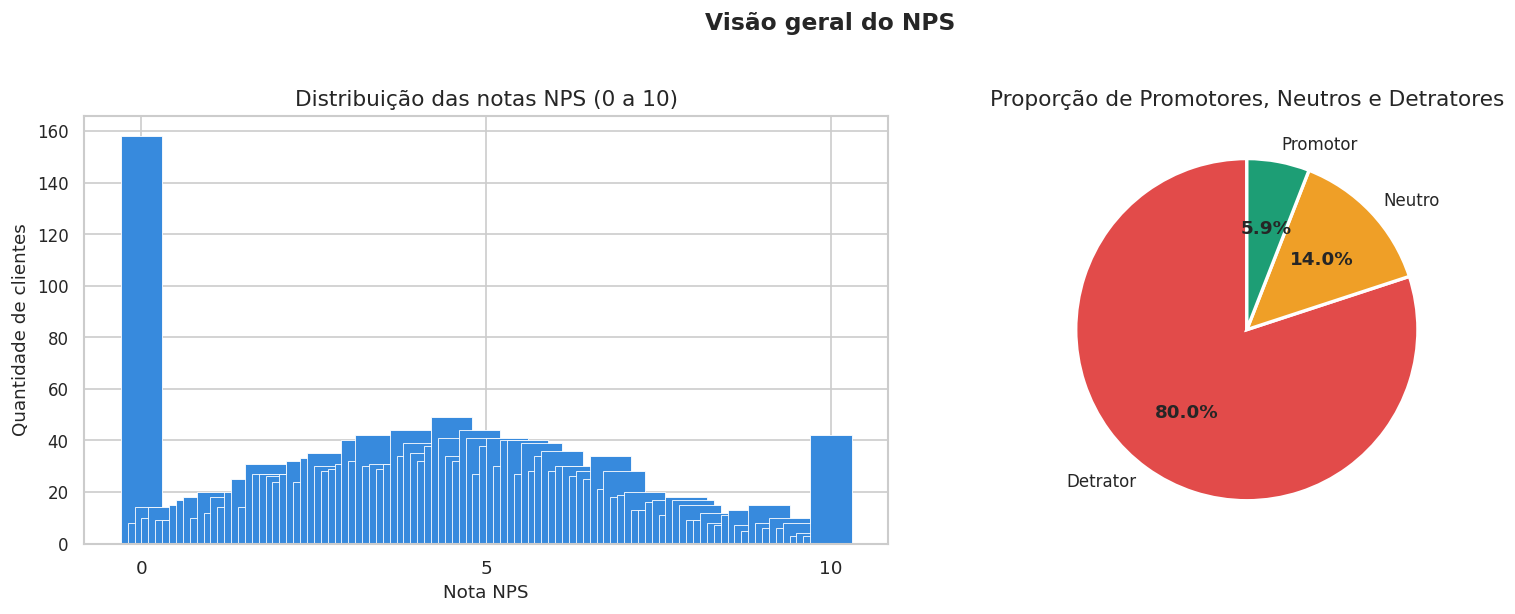


⚠ 80% dos clientes são Detratores — sinal de alerta crítico para o negócio.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: distribuição das notas NPS ---
ax1 = axes[0]
contagem = df['nps_score'].value_counts().sort_index()
ax1.bar(contagem.index, contagem.values, color='#378ADD', edgecolor='white', linewidth=0.5, width=0.6)
ax1.set_title('Distribuição das notas NPS (0 a 10)')
ax1.set_xlabel('Nota NPS')
ax1.set_ylabel('Quantidade de clientes')
ax1.set_xticks([0, 5, 10])
ax1.set_xticklabels(['0', '5', '10'], fontsize=11)
ax1.tick_params(axis='x', rotation=0)

# --- Gráfico 2: proporção por segmento ---
ax2 = axes[1]
segmentos = df['nps_segment'].value_counts()
cores_pizza = [CORES_NPS[s] for s in segmentos.index]
wedges, texts, autotexts = ax2.pie(
    segmentos,
    labels=segmentos.index,
    colors=cores_pizza,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax2.set_title('Proporção de Promotores, Neutros e Detratores')

plt.suptitle('Visão geral do NPS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/var', bbox_inches='tight')
plt.show()

print(f'\n⚠ 80% dos clientes são Detratores — sinal de alerta crítico para o negócio.')

## 6. Correlações com variáveis operacionais

Identificando quais variáveis do dataset têm maior relação linear com o NPS.

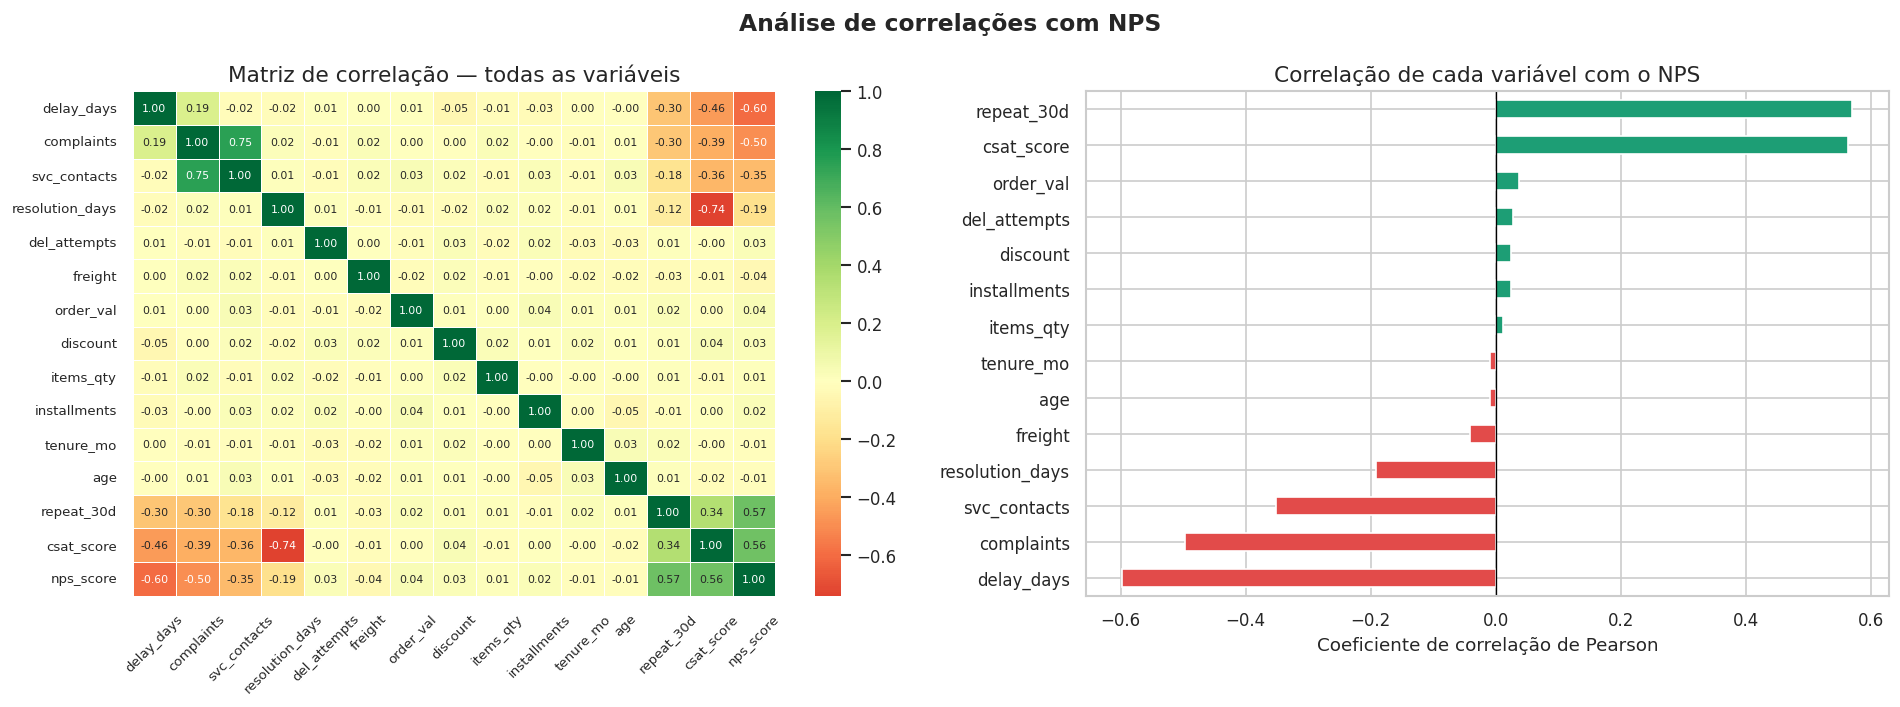

Top 5 variáveis com maior correlação (negativa) com NPS:
delay_days        -0.597
complaints        -0.497
svc_contacts      -0.351
resolution_days   -0.191
freight           -0.041
Name: nps_score, dtype: float64


In [19]:
# Selecionar apenas variáveis operacionais relevantes (excluir IDs e target duplicado)
colunas_analise = [
    'delivery_delay_days', 'complaints_count', 'customer_service_contacts',
    'resolution_time_days', 'delivery_attempts', 'freight_value',
    'order_value', 'discount_value', 'items_quantity',
    'payment_installments', 'customer_tenure_months', 'customer_age',
    'repeat_purchase_30d', 'csat_internal_score', 'nps_score']

# Nomes curtos para evitar sobreposição no eixo Y
labels_curtos = {
    'delivery_delay_days':       'delay_days',
    'complaints_count':          'complaints',
    'customer_service_contacts': 'svc_contacts',
    'resolution_time_days':      'resolution_days',
    'delivery_attempts':         'del_attempts',
    'freight_value':             'freight',
    'order_value':               'order_val',
    'discount_value':            'discount',
    'items_quantity':            'items_qty',
    'payment_installments':      'installments',
    'customer_tenure_months':    'tenure_mo',
    'customer_age':              'age',
    'repeat_purchase_30d':       'repeat_30d',
    'csat_internal_score':       'csat_score',
    'nps_score':                 'nps_score'}

# Matriz de correlação
corr_matrix = df[colunas_analise].corr()
corr_renamed = corr_matrix.copy()
corr_renamed.index   = [labels_curtos.get(c, c) for c in corr_renamed.index]
corr_renamed.columns = [labels_curtos.get(c, c) for c in corr_renamed.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Heatmap completo ---
sns.heatmap(
    corr_renamed,
    ax=axes[0],
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    annot_kws={'size': 6.5}
)
axes[0].set_title('Matriz de correlação — todas as variáveis')
axes[0].tick_params(axis='x', labelsize=8, rotation=45)
axes[0].tick_params(axis='y', labelsize=8, rotation=0)

# --- Barras: correlação com nps_score ---
corr_nps = corr_matrix['nps_score'].drop('nps_score').sort_values()
corr_nps.index = [labels_curtos.get(c, c) for c in corr_nps.index]
cores = ['#E24B4A' if v < 0 else '#1D9E75' for v in corr_nps]
corr_nps.plot(kind='barh', ax=axes[1], color=cores, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlação de cada variável com o NPS')
axes[1].set_xlabel('Coeficiente de correlação de Pearson')

plt.suptitle('Análise de correlações com NPS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/var', bbox_inches='tight')
plt.show()

print('Top 5 variáveis com maior correlação (negativa) com NPS:')
print(corr_nps.head(5).round(3))

## 7. Análise comparativa por segmento NPS

Comparando o comportamento médio de cada indicador operacional entre Promotores, Neutros e Detratores.

In [ ]:
# Variáveis operacionais para comparação
vars_operacionais = [
    'delivery_delay_days', 'complaints_count',
    'customer_service_contacts', 'resolution_time_days',
    'repeat_purchase_30d', 'delivery_attempts'
]

# Tabela de médias por segmento
medias_segmento = df.groupby('nps_segment')[vars_operacionais].mean().round(2)
print('Médias por segmento NPS:')
medias_segmento

Médias por segmento NPS:


,delivery_delay_days,complaints_count,customer_service_contacts,resolution_time_days,repeat_purchase_30d,delivery_attempts
nps_segment,,,,,,
Detrator,2.47,4.52,1.66,5.73,0.0,2.00
Neutro,1.19,2.85,1.07,4.72,0.2,2.03
Promotor,0.73,2.26,0.70,3.95,1.0,2.09


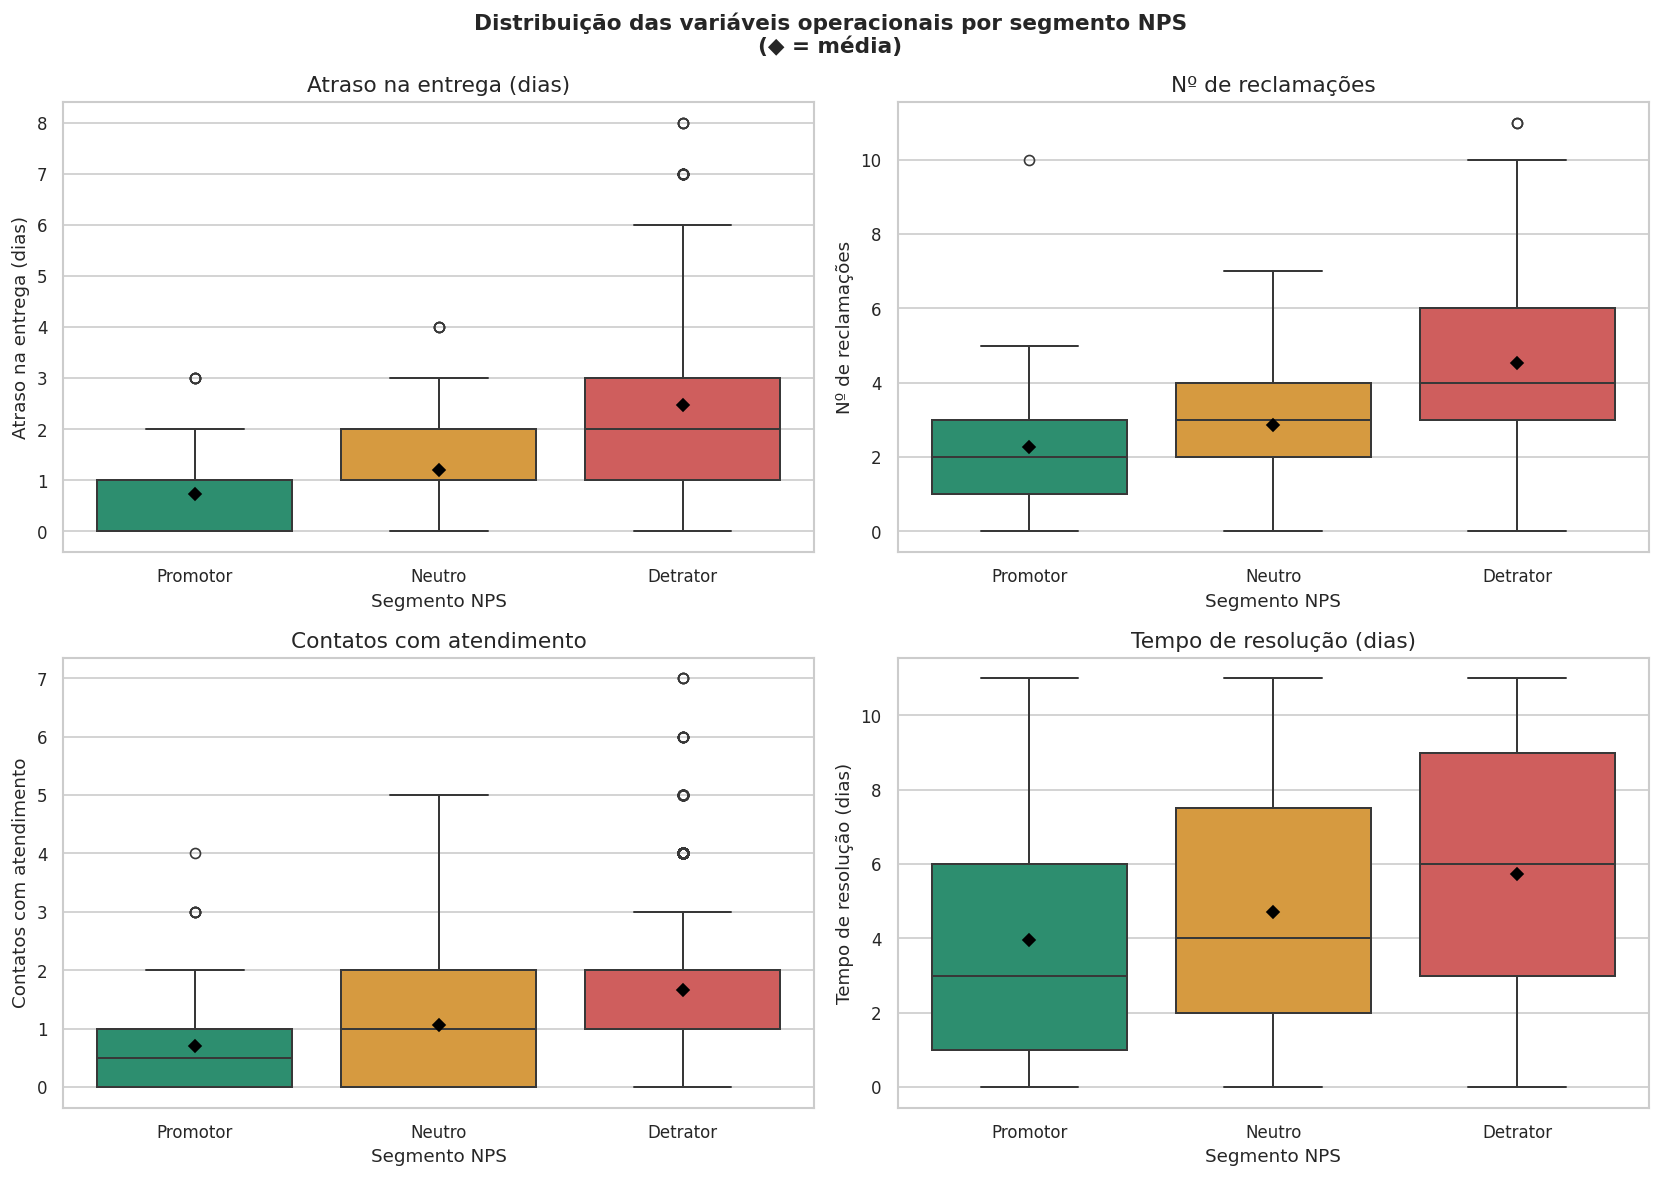

In [ ]:
# Visualização: boxplots das principais variáveis por segmento
vars_plot = [
    ('delivery_delay_days',        'Atraso na entrega (dias)'),
    ('complaints_count',           'Nº de reclamações'),
    ('customer_service_contacts',  'Contatos com atendimento'),
    ('resolution_time_days',       'Tempo de resolução (dias)')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ordem_segmentos = ['Promotor', 'Neutro', 'Detrator']

for ax, (col, titulo) in zip(axes.flat, vars_plot):
    sns.boxplot(
        data=df,
        x='nps_segment',
        y=col,
        order=ordem_segmentos,
        palette=CORES_NPS,
        ax=ax,
        linewidth=1.2
    )
    # Adicionar média como ponto
    medias = df.groupby('nps_segment')[col].mean()
    for i, seg in enumerate(ordem_segmentos):
        ax.plot(i, medias[seg], 'D', color='black', markersize=5, zorder=5)
    ax.set_title(titulo)
    ax.set_xlabel('Segmento NPS')
    ax.set_ylabel(titulo)

plt.suptitle('Distribuição das variáveis operacionais por segmento NPS\n(◆ = média)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/var', bbox_inches='tight')
plt.show()

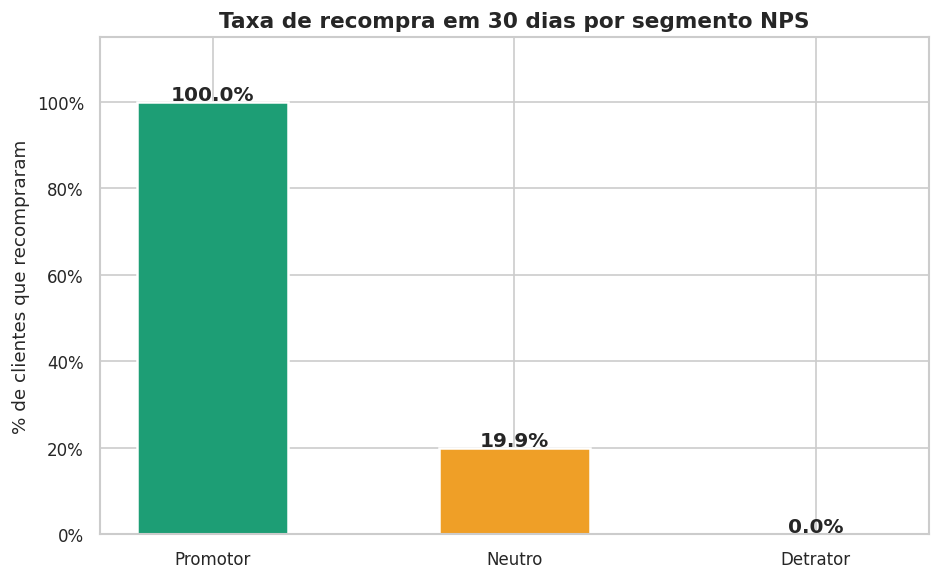

Promotores recompram: 100% | Neutros: ~20% | Detratores: 0%
A diferença na recompra entre Promotor e Detrator é absoluta — impacto direto em receita.


In [ ]:
# Análise de recompra por segmento — impacto financeiro direto
fig, ax = plt.subplots(figsize=(8, 5))

taxa_recompra = df.groupby('nps_segment')['repeat_purchase_30d'].mean() * 100
taxa_recompra = taxa_recompra.reindex(['Promotor', 'Neutro', 'Detrator'])

barras = ax.bar(
    taxa_recompra.index,
    taxa_recompra.values,
    color=[CORES_NPS[s] for s in taxa_recompra.index],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Rótulos nas barras
for barra, val in zip(barras, taxa_recompra.values):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', fontsize=12, fontweight='bold'
    )

ax.set_title('Taxa de recompra em 30 dias por segmento NPS', fontsize=13, fontweight='bold')
ax.set_ylabel('% de clientes que recompraram')
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('/var', bbox_inches='tight')
plt.show()

print('Promotores recompram: 100% | Neutros: ~20% | Detratores: 0%')
print('A diferença na recompra entre Promotor e Detrator é absoluta — impacto direto em receita.')

## 8. Pontos de ruptura na experiência do cliente

Identificando em que momento (qual nível de atraso, quantos contatos com atendimento) o NPS cai de forma mais acentuada.

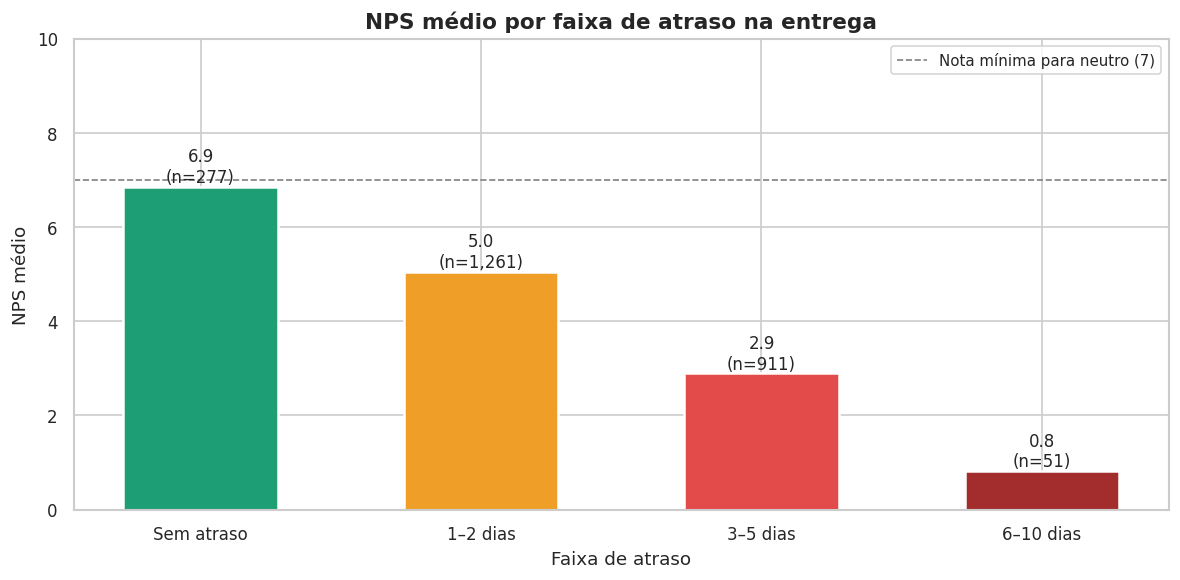

Ponto de ruptura claro: a partir de 3 dias de atraso, o NPS médio cai abaixo de 3.
Pedidos sem atraso têm NPS médio de 6.9 — ainda na zona de detrator, mas muito melhor.


In [ ]:
# Ponto de ruptura 1: atraso na entrega
df['faixa_atraso'] = pd.cut(
    df['delivery_delay_days'],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=['Sem atraso', '1–2 dias', '3–5 dias', '6–10 dias', '10+ dias']
)

nps_por_atraso = df.groupby('faixa_atraso')['nps_score'].agg(['mean', 'count']).round(2)
nps_por_atraso.columns = ['NPS médio', 'Nº pedidos']

fig, ax = plt.subplots(figsize=(10, 5))

cores_atraso = ['#1D9E75', '#EF9F27', '#E24B4A', '#A32D2D', '#501313']
barras = ax.bar(
    nps_por_atraso.index,
    nps_por_atraso['NPS médio'],
    color=cores_atraso[:len(nps_por_atraso)],
    edgecolor='white',
    linewidth=1.5,
    width=0.55
)

for barra, (idx, row) in zip(barras, nps_por_atraso.iterrows()):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.1,
        f'{row["NPS médio"]:.1f}\n(n={int(row["Nº pedidos"]):,})',
        ha='center', fontsize=10
    )

# Linha de referência: nota mínima de neutro (7)
ax.axhline(7, color='gray', linestyle='--', linewidth=1, label='Nota mínima para neutro (7)')
ax.legend(fontsize=9)
ax.set_title('NPS médio por faixa de atraso na entrega', fontsize=13, fontweight='bold')
ax.set_xlabel('Faixa de atraso')
ax.set_ylabel('NPS médio')
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig('/var', bbox_inches='tight')
plt.show()

print('Ponto de ruptura claro: a partir de 3 dias de atraso, o NPS médio cai abaixo de 3.')
print('Pedidos sem atraso têm NPS médio de 6.9 — ainda na zona de detrator, mas muito melhor.')

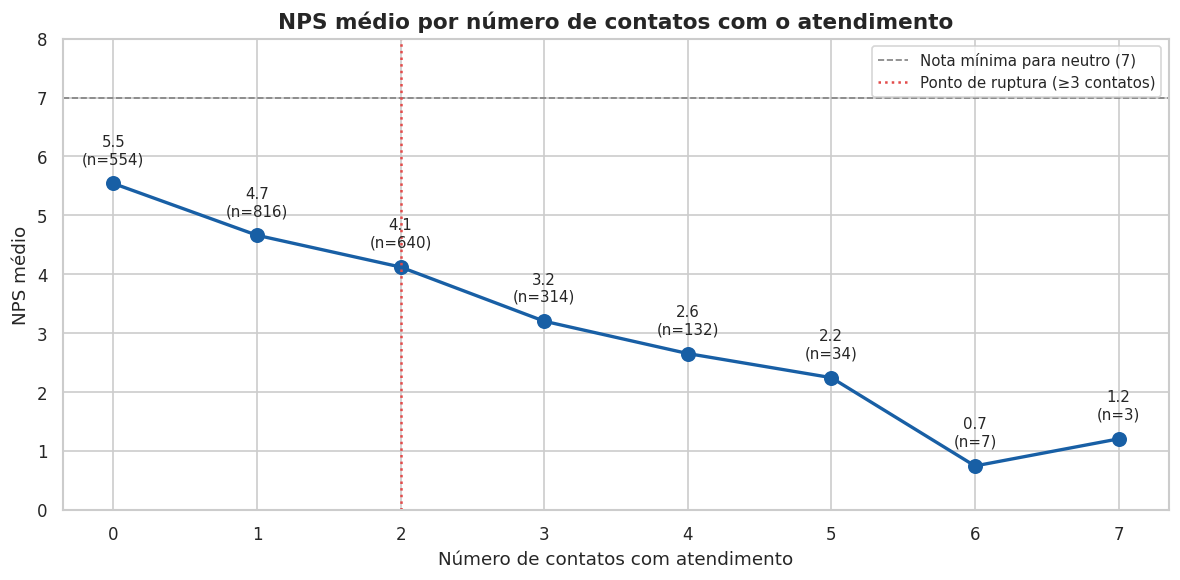

A partir do 3º contato com atendimento, o NPS médio cai abaixo de 3.2.
Cada contato adicional representa queda de ~0.8 pontos no NPS médio.


In [ ]:
# Ponto de ruptura 2: contatos com atendimento
nps_por_contatos = df.groupby('customer_service_contacts')['nps_score'].agg(['mean', 'count']).round(2)
nps_por_contatos.columns = ['NPS médio', 'Nº pedidos']

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    nps_por_contatos.index,
    nps_por_contatos['NPS médio'],
    marker='o', markersize=8, linewidth=2,
    color='#185FA5'
)

# Anotar cada ponto
for x, (idx, row) in zip(nps_por_contatos.index, nps_por_contatos.iterrows()):
    ax.annotate(
        f'{row["NPS médio"]:.1f}\n(n={int(row["Nº pedidos"]):,})',
        xy=(x, row['NPS médio']),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center', fontsize=9
    )

ax.axhline(7, color='gray', linestyle='--', linewidth=1, label='Nota mínima para neutro (7)')
ax.axvline(2, color='#E24B4A', linestyle=':', linewidth=1.5, label='Ponto de ruptura (≥3 contatos)')
ax.legend(fontsize=9)
ax.set_title('NPS médio por número de contatos com o atendimento', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de contatos com atendimento')
ax.set_ylabel('NPS médio')
ax.set_ylim(0, 8)
ax.set_xticks(nps_por_contatos.index)

plt.tight_layout()
plt.savefig('/var', bbox_inches='tight')
plt.show()

print('A partir do 3º contato com atendimento, o NPS médio cai abaixo de 3.2.')
print('Cada contato adicional representa queda de ~0.8 pontos no NPS médio.')

## 9. Análise por perfil de cliente

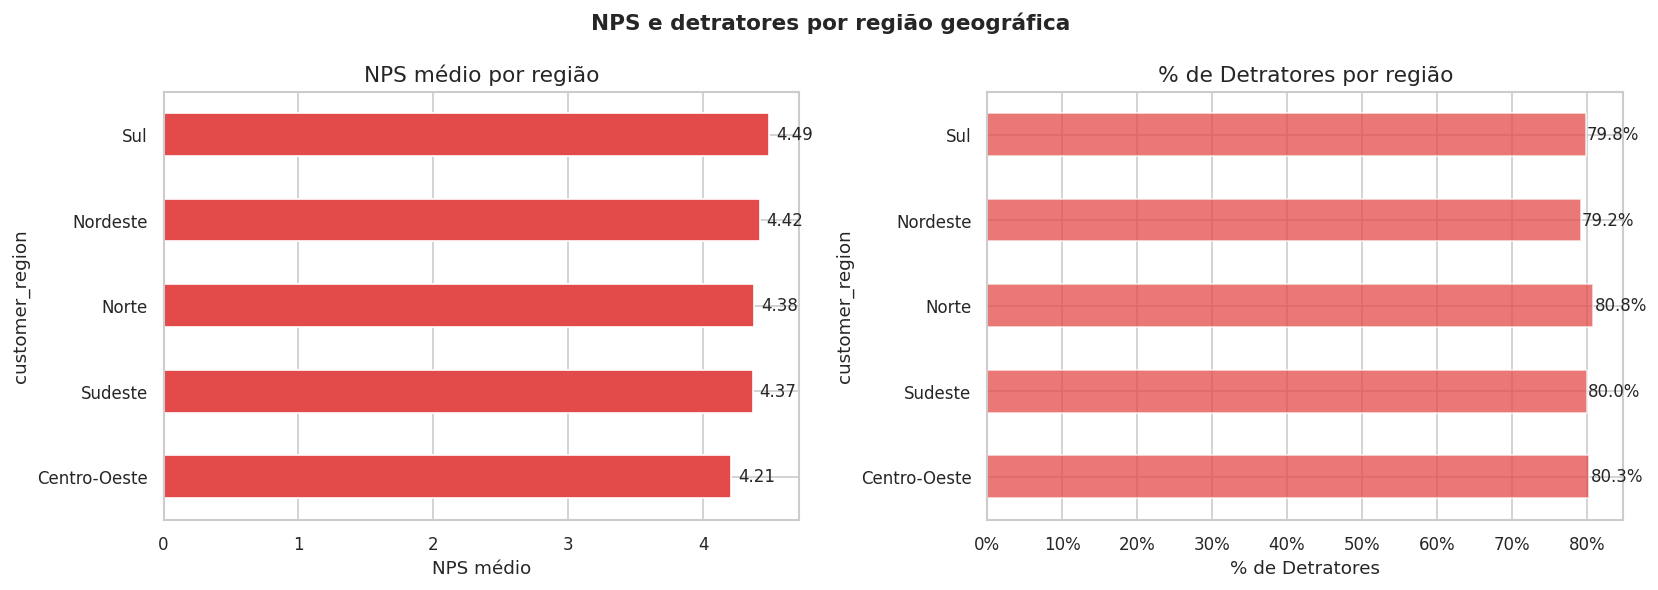

In [ ]:
# NPS médio por região geográfica
nps_regiao = df.groupby('customer_region').agg(
    nps_medio=('nps_score', 'mean'),
    total=('nps_score', 'count'),
    pct_detratores=('nps_segment', lambda x: (x == 'Detrator').mean() * 100)
).round(2).sort_values('nps_medio')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NPS médio por região
cores_reg = ['#E24B4A' if v < 5 else '#EF9F27' if v < 7 else '#1D9E75'
             for v in nps_regiao['nps_medio']]
nps_regiao['nps_medio'].plot(
    kind='barh', ax=axes[0], color=cores_reg, edgecolor='white'
)
axes[0].set_title('NPS médio por região')
axes[0].set_xlabel('NPS médio')
for i, v in enumerate(nps_regiao['nps_medio']):
    axes[0].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=10)

# % de detratores por região
nps_regiao['pct_detratores'].plot(
    kind='barh', ax=axes[1], color='#E24B4A', alpha=0.75, edgecolor='white'
)
axes[1].set_title('% de Detratores por região')
axes[1].set_xlabel('% de Detratores')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())
for i, v in enumerate(nps_regiao['pct_detratores']):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)

plt.suptitle('NPS e detratores por região geográfica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/var', bbox_inches='tight')
plt.show()

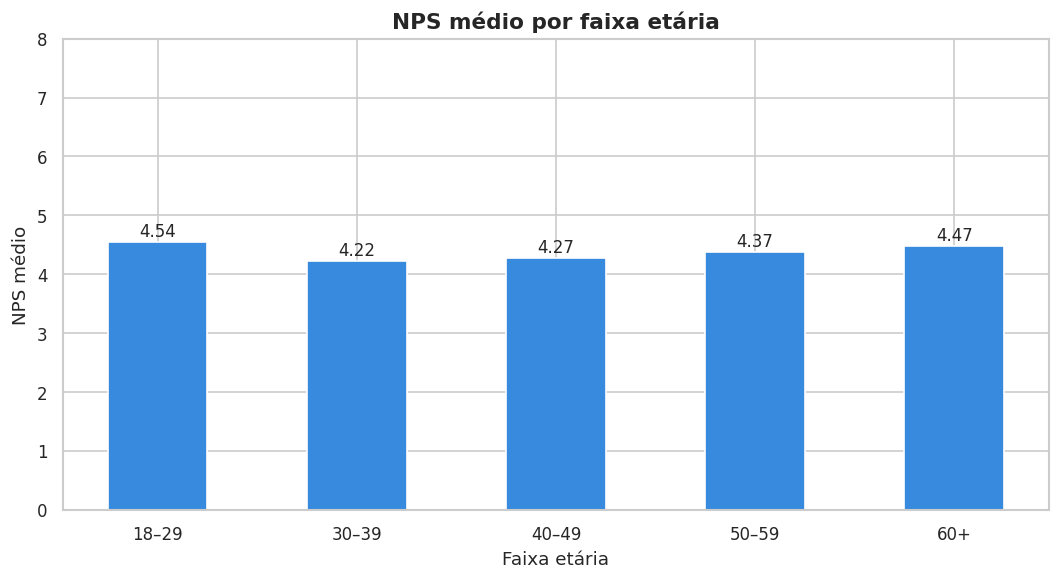

NPS médio por faixa etária:
faixa_etaria
18–29    4.54
30–39    4.22
40–49    4.27
50–59    4.37
60+      4.47
Name: nps_score, dtype: float64


In [ ]:
# NPS por faixa etária
df['faixa_etaria'] = pd.cut(
    df['customer_age'],
    bins=[17, 29, 39, 49, 59, 100],
    labels=['18–29', '30–39', '40–49', '50–59', '60+']
)

nps_idade = df.groupby('faixa_etaria')['nps_score'].mean().round(2)
pct_det_idade = df.groupby('faixa_etaria').apply(
    lambda x: (x['nps_segment'] == 'Detrator').mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(nps_idade.index, nps_idade.values, color='#378ADD', edgecolor='white', width=0.5)
ax.set_title('NPS médio por faixa etária', fontsize=13, fontweight='bold')
ax.set_xlabel('Faixa etária')
ax.set_ylabel('NPS médio')
ax.set_ylim(0, 8)
for i, (faixa, val) in enumerate(nps_idade.items()):
    ax.text(i, val + 0.1, f'{val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/var', bbox_inches='tight')
plt.show()

print('NPS médio por faixa etária:')
print(nps_idade)

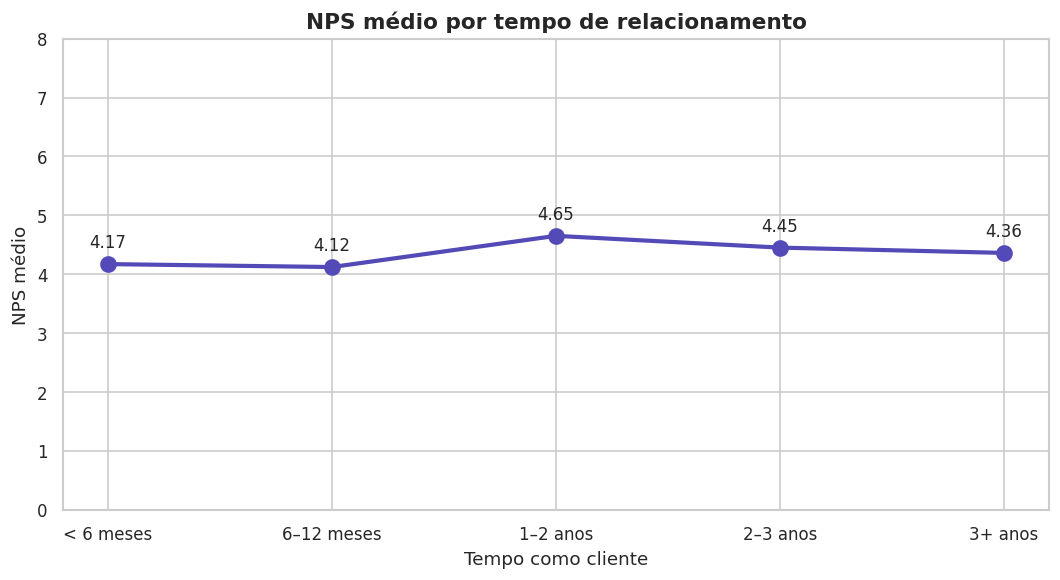

NPS médio por tempo de relacionamento:
faixa_tenure
< 6 meses     4.17
6–12 meses    4.12
1–2 anos      4.65
2–3 anos      4.45
3+ anos       4.36
Name: nps_score, dtype: float64


In [ ]:
# NPS por tempo de relacionamento com a empresa
df['faixa_tenure'] = pd.cut(
    df['customer_tenure_months'],
    bins=[-1, 6, 12, 24, 36, 1000],
    labels=['< 6 meses', '6–12 meses', '1–2 anos', '2–3 anos', '3+ anos']
)

nps_tenure = df.groupby('faixa_tenure')['nps_score'].mean().round(2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(nps_tenure.index, nps_tenure.values,
        marker='o', markersize=9, linewidth=2.5, color='#534AB7')
ax.set_title('NPS médio por tempo de relacionamento', fontsize=13, fontweight='bold')
ax.set_xlabel('Tempo como cliente')
ax.set_ylabel('NPS médio')
ax.set_ylim(0, 8)
for i, (faixa, val) in enumerate(nps_tenure.items()):
    ax.annotate(f'{val:.2f}', xy=(i, val), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/var', bbox_inches='tight')
plt.show()

print('NPS médio por tempo de relacionamento:')
print(nps_tenure)

## 10. Conclusões gerenciais

> Esta seção traduz os achados técnicos em linguagem acessível para gestores e stakeholders não técnicos.

In [ ]:
print("""=======================================================================
RESUMO EXECUTIVO — PRINCIPAIS ACHADOS DA EDA
=======================================================================

1. SITUAÇÃO CRÍTICA DO NPS
   80% dos clientes são Detratores. O NPS calculado da empresa está
   muito abaixo do benchmark do setor (30 a 50 pontos para e-commerce).
   Isso representa um risco sério de perda de clientes e reputação.

2. PRINCIPAL CAUSADOR DE INSATISFAÇÃO: ATRASO NA ENTREGA
   É a variável com maior correlação negativa com o NPS (-0.60).
   - Pedidos sem atraso: NPS médio de 6.9
   - Atraso de 1-2 dias: NPS médio de 5.1 (queda de ~26%)
   - Atraso de 3-5 dias: NPS médio de 2.9 (queda de ~58%)
   - Atraso de 6-10 dias: NPS médio de 0.8 (quase zero)
   PONTO DE RUPTURA: 3 dias de atraso destroem completamente a satisfação.

3. SEGUNDO FATOR CRÍTICO: RECLAMAÇÕES E CONTATOS COM ATENDIMENTO
   Detratores têm em média 4.5 reclamações vs 2.3 dos Promotores.
   Cada contato adicional com atendimento reduz o NPS em ~0.8 pontos.
   A partir do 3º contato, o cliente já está em zona de Detrator.

4. IMPACTO DIRETO NA RECEITA: RECOMPRA
   - Promotores: 100% recompram em 30 dias
   - Neutros: ~20% recompram
   - Detratores: 0% recompram
   Com 80% de Detratores, a empresa perde sistematicamente receita
   de recorrência — o cliente mais barato de adquirir.

5. PERFIL DO CLIENTE EM RISCO
   - Região Centro-Oeste tem NPS mais baixo (4.2 vs 4.5 no Sul)
   - Diferenças por faixa etária e tempo de relacionamento são menores
   - Os indicadores operacionais (atraso, reclamações) explicam a
     variação de NPS muito mais do que o perfil demográfico

RECOMENDAÇÃO PRINCIPAL:
   Focar esforços na redução de atrasos logísticos — especialmente
   evitar atrasos acima de 3 dias — e na resolução de problemas
   no primeiro contato com o atendimento (FCR).
=======================================================================
""")

RESUMO EXECUTIVO — PRINCIPAIS ACHADOS DA EDA

1. SITUAÇÃO CRÍTICA DO NPS
   80% dos clientes são Detratores. O NPS calculado da empresa está
   muito abaixo do benchmark do setor (30 a 50 pontos para e-commerce).
   Isso representa um risco sério de perda de clientes e reputação.

2. PRINCIPAL CAUSADOR DE INSATISFAÇÃO: ATRASO NA ENTREGA
   É a variável com maior correlação negativa com o NPS (-0.60).
   - Pedidos sem atraso: NPS médio de 6.9
   - Atraso de 1-2 dias: NPS médio de 5.1 (queda de ~26%)
   - Atraso de 3-5 dias: NPS médio de 2.9 (queda de ~58%)
   - Atraso de 6-10 dias: NPS médio de 0.8 (quase zero)
   PONTO DE RUPTURA: 3 dias de atraso destroem completamente a satisfação.

3. SEGUNDO FATOR CRÍTICO: RECLAMAÇÕES E CONTATOS COM ATENDIMENTO
   Detratores têm em média 4.5 reclamações vs 2.3 dos Promotores.
   Cada contato adicional com atendimento reduz o NPS em ~0.8 pontos.
   A partir do 3º contato, o cliente já está em zona de Detrator.

4. IMPACTO DIRETO NA RECEITA: RECOMPRA